In [1]:
# 食べれるキノコか食べれないキノコか判別するオリジナルAI

# 必要なライブラリのimport
import tensorflow as tf
import matplotlib.pyplot as plt  # グラフ描画に利用
import pandas as pd  # CSV操作のため利用
import numpy as np

# データの分割
from sklearn.model_selection import train_test_split


In [19]:
# DataFrameで全ての列を表示する設定
pd.options.display.max_columns = None

In [20]:
# Kerasを利用して画像を読み込み、データセットを作成する
dataset_base = pd.read_csv("./mushrooms.csv")
dataset_base.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [21]:
# 日本語ラベルの定義
# 列名（英語 -> 日本語）のマッピング
column_japanese = {
    'class': '分類', 'cap-shape': 'カサの形', 'cap-surface': 'カサの表面',
    'cap-color': 'カサの色', 'bruises': '傷', 'odor': '匂い',
    'gill-attachment': 'ヒダの付き方', 'gill-spacing': 'ヒダの間隔',
    'gill-size': 'ヒダの大きさ', 'gill-color': 'ヒダの色', 'stalk-shape': '柄の形',
    'stalk-root': '柄の根元', 'stalk-surface-above-ring': '柄の表面（ツバより上）',
    'stalk-surface-below-ring': '柄の表面（ツバより下）', 'stalk-color-above-ring': '柄の色（ツバより上）',
    'stalk-color-below-ring': '柄の色（ツバより下）', 'veil-type': '内被膜の種類',
    'veil-color': '内被膜の色', 'ring-number': 'ツバの数', 'ring-type': 'ツバの種類',
    'spore-print-color': '胞子紋の色', 'population': '個体数', 'habitat': '生育環境'
}

japanese_column_list = [
    '分類', 'カサの形', 'カサの表面', 'カサの色', '傷', '匂い', 
    'ヒダの付き方', 'ヒダの間隔', 'ヒダの大きさ', 'ヒダの色', 
    '柄の形', '柄の根元', '柄の表面（ツバより上）', '柄の表面（ツバより下）', 
    '柄の色（ツバより上）', '柄の色（ツバより下）', '内被膜の種類', 
    '内被膜の色', 'ツバの数', 'ツバの種類', '胞子紋の色', '個体数', '生育環境'
]


In [22]:
# 元のデータフレームをコピー
dataset_jp = dataset_base.copy()

In [23]:
# 列名を日本語に一括で変更
dataset_jp.rename(columns=column_japanese, inplace=True)

In [24]:
# データの形状を確認
dataset_jp.shape


(8124, 23)

In [25]:
# 全体的な情報を表示
dataset_jp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   分類           8124 non-null   object
 1   カサの形         8124 non-null   object
 2   カサの表面        8124 non-null   object
 3   カサの色         8124 non-null   object
 4   傷            8124 non-null   object
 5   匂い           8124 non-null   object
 6   ヒダの付き方       8124 non-null   object
 7   ヒダの間隔        8124 non-null   object
 8   ヒダの大きさ       8124 non-null   object
 9   ヒダの色         8124 non-null   object
 10  柄の形          8124 non-null   object
 11  柄の根元         8124 non-null   object
 12  柄の表面（ツバより上）  8124 non-null   object
 13  柄の表面（ツバより下）  8124 non-null   object
 14  柄の色（ツバより上）   8124 non-null   object
 15  柄の色（ツバより下）   8124 non-null   object
 16  内被膜の種類       8124 non-null   object
 17  内被膜の色        8124 non-null   object
 18  ツバの数         8124 non-null   object
 19  ツバの種類        8124 non-null 

In [26]:
# 行番号を確認
dataset_jp.index.values

array([   0,    1,    2, ..., 8121, 8122, 8123])

In [27]:
# 列ラベルを確認
dataset_jp.columns.values

array(['分類', 'カサの形', 'カサの表面', 'カサの色', '傷', '匂い', 'ヒダの付き方', 'ヒダの間隔',
       'ヒダの大きさ', 'ヒダの色', '柄の形', '柄の根元', '柄の表面（ツバより上）', '柄の表面（ツバより下）',
       '柄の色（ツバより上）', '柄の色（ツバより下）', '内被膜の種類', '内被膜の色', 'ツバの数', 'ツバの種類',
       '胞子紋の色', '個体数', '生育環境'], dtype=object)

In [28]:
# 要約統計量を表示
dataset_jp.describe()

,分類,カサの形,カサの表面,カサの色,傷,匂い,ヒダの付き方,ヒダの間隔,ヒダの大きさ,ヒダの色,柄の形,柄の根元,柄の表面（ツバより上）,柄の表面（ツバより下）,柄の色（ツバより上）,柄の色（ツバより下）,内被膜の種類,内被膜の色,ツバの数,ツバの種類,胞子紋の色,個体数,生育環境
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [29]:
# 先頭5行を表示
dataset_jp.head()

,分類,カサの形,カサの表面,カサの色,傷,匂い,ヒダの付き方,ヒダの間隔,ヒダの大きさ,ヒダの色,柄の形,柄の根元,柄の表面（ツバより上）,柄の表面（ツバより下）,柄の色（ツバより上）,柄の色（ツバより下）,内被膜の種類,内被膜の色,ツバの数,ツバの種類,胞子紋の色,個体数,生育環境
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [30]:
# カテゴリー変数作成
dataset_jp = pd.get_dummies(data=dataset_jp, columns=japanese_column_list[1:])

In [31]:
# 列ラベルを確認
dataset_jp.columns.values

array(['分類', 'カサの形_b', 'カサの形_c', 'カサの形_f', 'カサの形_k', 'カサの形_s', 'カサの形_x',
       'カサの表面_f', 'カサの表面_g', 'カサの表面_s', 'カサの表面_y', 'カサの色_b', 'カサの色_c',
       'カサの色_e', 'カサの色_g', 'カサの色_n', 'カサの色_p', 'カサの色_r', 'カサの色_u',
       'カサの色_w', 'カサの色_y', '傷_f', '傷_t', '匂い_a', '匂い_c', '匂い_f', '匂い_l',
       '匂い_m', '匂い_n', '匂い_p', '匂い_s', '匂い_y', 'ヒダの付き方_a', 'ヒダの付き方_f',
       'ヒダの間隔_c', 'ヒダの間隔_w', 'ヒダの大きさ_b', 'ヒダの大きさ_n', 'ヒダの色_b', 'ヒダの色_e',
       'ヒダの色_g', 'ヒダの色_h', 'ヒダの色_k', 'ヒダの色_n', 'ヒダの色_o', 'ヒダの色_p',
       'ヒダの色_r', 'ヒダの色_u', 'ヒダの色_w', 'ヒダの色_y', '柄の形_e', '柄の形_t', '柄の根元_?',
       '柄の根元_b', '柄の根元_c', '柄の根元_e', '柄の根元_r', '柄の表面（ツバより上）_f',
       '柄の表面（ツバより上）_k', '柄の表面（ツバより上）_s', '柄の表面（ツバより上）_y', '柄の表面（ツバより下）_f',
       '柄の表面（ツバより下）_k', '柄の表面（ツバより下）_s', '柄の表面（ツバより下）_y', '柄の色（ツバより上）_b',
       '柄の色（ツバより上）_c', '柄の色（ツバより上）_e', '柄の色（ツバより上）_g', '柄の色（ツバより上）_n',
       '柄の色（ツバより上）_o', '柄の色（ツバより上）_p', '柄の色（ツバより上）_w', '柄の色（ツバより上）_y',
       '柄の色（ツバより下）_b', '柄の色（ツバより下）_c', '柄の色（ツバより下）_e', '柄の色（ツバより下）_g',
    

In [49]:
# 先頭5行を表示
dataset_jp.head()

,分類,カサの形_b,カサの形_c,カサの形_f,カサの形_k,カサの形_s,カサの形_x,カサの表面_f,カサの表面_g,カサの表面_s,カサの表面_y,カサの色_b,カサの色_c,カサの色_e,カサの色_g,カサの色_n,カサの色_p,カサの色_r,カサの色_u,カサの色_w,カサの色_y,傷_f,傷_t,匂い_a,匂い_c,匂い_f,匂い_l,匂い_m,匂い_n,匂い_p,匂い_s,匂い_y,ヒダの付き方_a,ヒダの付き方_f,ヒダの間隔_c,ヒダの間隔_w,ヒダの大きさ_b,ヒダの大きさ_n,ヒダの色_b,ヒダの色_e,ヒダの色_g,ヒダの色_h,ヒダの色_k,ヒダの色_n,ヒダの色_o,ヒダの色_p,ヒダの色_r,ヒダの色_u,ヒダの色_w,ヒダの色_y,柄の形_e,柄の形_t,柄の根元_?,柄の根元_b,柄の根元_c,柄の根元_e,柄の根元_r,柄の表面（ツバより上）_f,柄の表面（ツバより上）_k,柄の表面（ツバより上）_s,柄の表面（ツバより上）_y,柄の表面（ツバより下）_f,柄の表面（ツバより下）_k,柄の表面（ツバより下）_s,柄の表面（ツバより下）_y,柄の色（ツバより上）_b,柄の色（ツバより上）_c,柄の色（ツバより上）_e,柄の色（ツバより上）_g,柄の色（ツバより上）_n,柄の色（ツバより上）_o,柄の色（ツバより上）_p,柄の色（ツバより上）_w,柄の色（ツバより上）_y,柄の色（ツバより下）_b,柄の色（ツバより下）_c,柄の色（ツバより下）_e,柄の色（ツバより下）_g,柄の色（ツバより下）_n,柄の色（ツバより下）_o,柄の色（ツバより下）_p,柄の色（ツバより下）_w,柄の色（ツバより下）_y,内被膜の種類_p,内被膜の色_n,内被膜の色_o,内被膜の色_w,内被膜の色_y,ツバの数_n,ツバの数_o,ツバの数_t,ツバの種類_e,ツバの種類_f,ツバの種類_l,ツバの種類_n,ツバの種類_p,胞子紋の色_b,胞子紋の色_h,胞子紋の色_k,胞子紋の色_n,胞子紋の色_o,胞子紋の色_r,胞子紋の色_u,胞子紋の色_w,胞子紋の色_y,個体数_a,個体数_c,個体数_n,個体数_s,個体数_v,個体数_y,生育環境_d,生育環境_g,生育環境_l,生育環境_m,生育環境_p,生育環境_u,生育環境_w
0,1,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
1,0,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,True,False,False,False,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False
2,0,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
3,1,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,False,True,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False
4,0,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,True,True,False,False,False,False,False,True,False,False,False,False,Fals

In [47]:
# 'p' を 1 に、'e' を 0 に変換する p:poisonous e:edible
dataset_jp['分類'] = dataset_jp['分類'].map({'p': 1, 'e': 0})

In [48]:
# 欠損値の数の確認
dataset_jp.isnull().sum()

分類        0
カサの形_b    0
カサの形_c    0
カサの形_f    0
カサの形_k    0
         ..
生育環境_l    0
生育環境_m    0
生育環境_p    0
生育環境_u    0
生育環境_w    0
Length: 118, dtype: int64

In [50]:
# 欠損値の数の確認
dataset_jp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Columns: 118 entries, 分類 to 生育環境_w
dtypes: bool(117), int64(1)
memory usage: 991.8 KB


In [51]:
# Y:目的変数、X:説明変数
Y = np.array(dataset_jp.loc[:, '分類'])
X = np.array(dataset_jp.iloc[:, 1:])


In [52]:
# 型チェック
print(f"{type(Y)}, {type(X)}")

<class 'numpy.ndarray'>, <class 'numpy.ndarray'>


In [53]:
# Y:目的変数、X:説明変数の次元チェック
print("Y:", Y.shape)
print("X:", X.shape)


Y: (8124,)
X: (8124, 117)


In [54]:
# データ分割
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=0)
X_train, X_valid, Y_train, Y_valid = train_test_split(X_train, Y_train, test_size=0.3, random_state=0)

In [55]:
# 形状を確認
print("Y_train=", Y_train.shape, ", X_train=", X_train.shape)
print("Y_valid=", Y_valid.shape, ", X_valid=", X_valid.shape)
print("Y_test=", Y_test.shape, ", X_test=", X_test.shape)

Y_train= (3980,) , X_train= (3980, 117)
Y_valid= (1706,) , X_valid= (1706, 117)
Y_test= (2438,) , X_test= (2438, 117)


In [56]:
# モデルの初期化
model = tf.keras.Sequential([
    # 入力層
    tf.keras.Input(shape=(117,)),
    tf.keras.layers.Dense(117, activation='relu'),
    # 隠れ層
    tf.keras.layers.Dense(117, activation='relu'),
    # 出力層
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# モデルの構築
model.compile(optimizer = "rmsprop", loss='binary_crossentropy', metrics=['accuracy'])

In [57]:
# モデルの構造を表示
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 117)            │        13,806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 117)            │        13,806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           118 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,730 (108.32 KB)

 Trainable params: 27,730 (108.32 KB)

 Non-trainable params: 0 (0.00 B)

In [62]:
%%time
# 学習の実施
log = model.fit(X_train, Y_train, epochs=5000, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                            min_delta=0, patience=100,
                                                            verbose=1)],
                validation_data=(X_valid, Y_valid))

Epoch 1/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.8287e-07 - val_accuracy: 1.0000 - val_loss: 2.9146e-07
Epoch 2/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.6751e-07 - val_accuracy: 1.0000 - val_loss: 2.9077e-07
Epoch 3/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.7239e-07 - val_accuracy: 1.0000 - val_loss: 2.9001e-07
Epoch 4/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.7755e-07 - val_accuracy: 1.0000 - val_loss: 2.8926e-07
Epoch 5/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.5564e-07 - val_accuracy: 1.0000 - val_loss: 2.8850e-07
Epoch 6/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 1.8559e-07 - val_accuracy: 1.0000 - val_loss: 2.8775e-07
Epoch 7/5000
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 1.8491e-07 - val_accuracy: 1.0000 - val_loss: 2.8699e-07
Epoch 8/5000
125/125 ━━━━━━━━━━━━━

Text(0, 0.5, 'crossentropy')

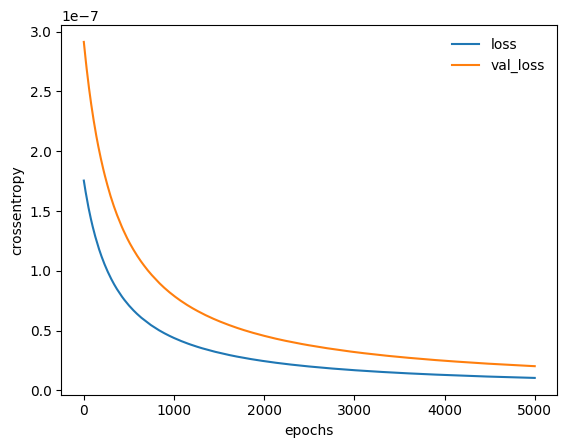

In [63]:
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False) # 凡例の表示
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [65]:
# predictで予測を行なう
Y_pred = model.predict(X_test)
Y_pred

77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[1.0000000e+00],
       [7.7688486e-14],
       [2.5928125e-12],
       ...,
       [1.0000000e+00],
       [9.9999994e-01],
       [1.0000000e+00]], dtype=float32)

In [66]:
# 二値分類は予測結果の確率が0.5以下なら0,
Y_pred_cls = (Y_pred > 0.5).astype("int32")
Y_pred_cls

array([[1],
       [0],
       [0],
       ...,
       [1],
       [1],
       [1]], dtype=int32)

In [71]:
# 形状を正解（目的変数）に合わせる
Y_pred_ = Y_pred_cls.reshape(-1)

[1 0 0 ... 1 1 1]
[1 0 0 ... 1 1 1]


In [68]:
# モデルの評価
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred_))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1272
           1       1.00      1.00      1.00      1166

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438

